In [11]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from PIL import Image
from scipy import signal as sig

# Projeto 1 - Sinais e Sistemas em Tempo Discreto - 2026/01
# Identificação
## Nome: Raul Myron Silva Amorim
## Matrícula: 200049712

# Questão 1

## Questão 1a (0.5 pontos)

O objetivo deste exercício é estudar a decimação e a interpolação de sinais. 
Escreva uma função em python que receba um sinal x[n] e retorne um sinal y[n] que seja a decimação por um fator de 2 do sinal de entrada x[n]. 

Em seguida, use a sua função para encontrar o sinal decimado para a entrada: 

$$ x = \left[1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0 \right]$$

In [12]:
### Código da questão 1a.

x = np.array([1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0])

def decimate(x):
    """Retorna y[n] = x[2n] — pega uma amostra a cada duas."""
    return x[::2]

y = decimate(x)

print("x[n]:", x)
print("y[n] (decimado):", y)


x[n]: [1 2 1 0 1 2 1 0 1 2 1 0 1 2 1 0 1 2 1 0]
y[n] (decimado): [1 1 1 1 1 1 1 1 1 1]


## Questão 1b (0.5 pontos)

Escreva uma função em python que receba um sinal y[n] e retorne um sinal z[n] que seja a interpolação por um fator de 2 do sinal de entrada y[n]. A sua função deve aumentar o número de amostras e assinalar um novo valor para as amostras criadas. Você pode escolher se as amostras interpoladas terão o valor médio das amostras ou o valor da amostra anterior. 

Em seguida, utilize a sua função para encontrar o sinal interpolado para o sinal y[n] da questão anterior (1a).


In [13]:
### Código da questão 1b.


def interpolar(y, mode='mean'):
    """
    Interpolar
    mode='mean': nova amostra = média das vizinhas
    mode='hold': nova amostra = valor da amostra anterior
    """
    N = len(y)
    z = np.zeros(2 * N)
    z[::2] = y  # posições pares recebem os valores originais

    if mode == 'mean':
        # média entre vizinhos (c/ exceção na última posição)
        z[1:-1:2] = (y[:-1] + y[1:]) / 2
        z[-1] = y[-1]  # última amostra sem vizinhança próxima
    elif mode == 'hold':
        z[1::2] = y  # amostra anterior
    return z

z = interpolar(y, mode='mean')
print("y[n] (decimado 1a):", y)
print("z[n] (interpolado 1b, mean/m´´edia):", z)

y[n] (decimado 1a): [1 1 1 1 1 1 1 1 1 1]
z[n] (interpolado 1b, mean/m´´edia): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Questão 1c (1 ponto)

Uma imagem é um sinal discreto de duas dimensões. 
Escrevemos I(x,y) para representar esta imagem como uma matriz bidimensional de dimensões (w x h), onde w é a largura da imagem e h a sua altura.

Para imagens, fazemos a decimação e a interpolação separadamente, para todas as linhas e, em seguida, para todas as colunas (ou vice-versa), considerando que cada linha ou coluna é um sinal de uma dimensão.

Aplique o seu algoritmo de decimação sucessivamente até obter uma imagem com tamanho (w/16 x h/16), isto é, aplique o algoritmo 4 vezes seguidas, mostrando a imagem resultante.


Imagem original: 512 x 512


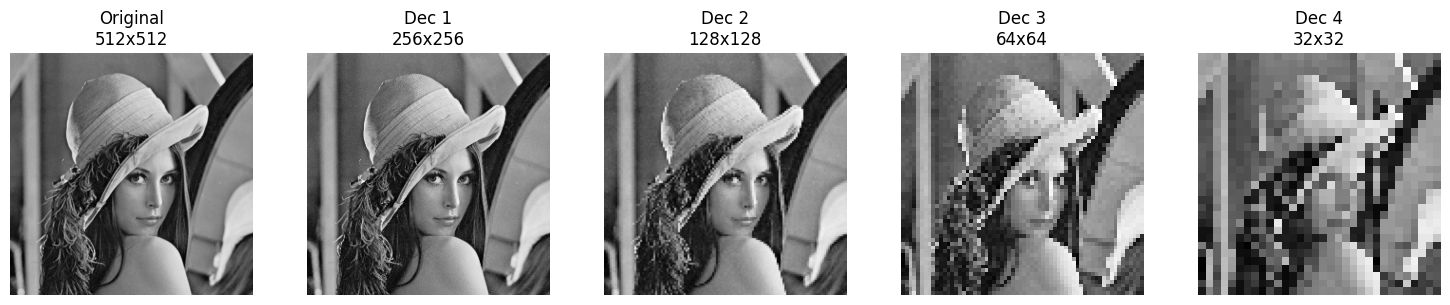

In [14]:
### Código da questão 1c.

def decimate_image(A):
    return A[::2, ::2]

im = Image.open("lena.bmp")
A = np.array(im)
h, w = A.shape
print(f"\nImagem original: {h} x {w}")

A_dec = A.copy()
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(A_dec, cmap='gray')
axes[0].set_title(f"Original\n{A_dec.shape[0]}x{A_dec.shape[1]}")
axes[0].axis('off')

A_dec = decimate_image(A_dec)
axes[1].imshow(A_dec, cmap='gray')
axes[1].set_title(f"Dec 1\n{A_dec.shape[0]}x{A_dec.shape[1]}")
axes[1].axis('off')

A_dec = decimate_image(A_dec)
axes[2].imshow(A_dec, cmap='gray')
axes[2].set_title(f"Dec 2\n{A_dec.shape[0]}x{A_dec.shape[1]}")
axes[2].axis('off')

A_dec = decimate_image(A_dec)
axes[3].imshow(A_dec, cmap='gray')
axes[3].set_title(f"Dec 3\n{A_dec.shape[0]}x{A_dec.shape[1]}")
axes[3].axis('off')

A_dec = decimate_image(A_dec)
axes[4].imshow(A_dec, cmap='gray')
axes[4].set_title(f"Dec 4\n{A_dec.shape[0]}x{A_dec.shape[1]}")
axes[4].axis('off')

plt.tight_layout()
plt.show()


## Questão 1d (1 ponto)

Utilizando como entrada a imagem decimada (de tamanho w/16 x h/16) da questão anterior (1c), aplique o seu algoritmo de interpolação sucessivamente até obter uma imagem com tamanho (w x h), isto é, aplique o algoritmo 4 vezes seguidas, mostrando a imagem resultante. Compare a imagem original com a imagem que foi decimada/interpolada. 

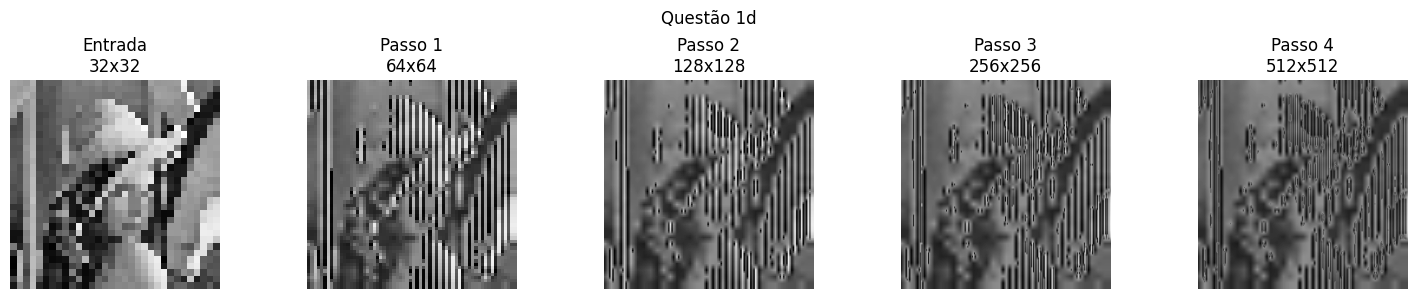

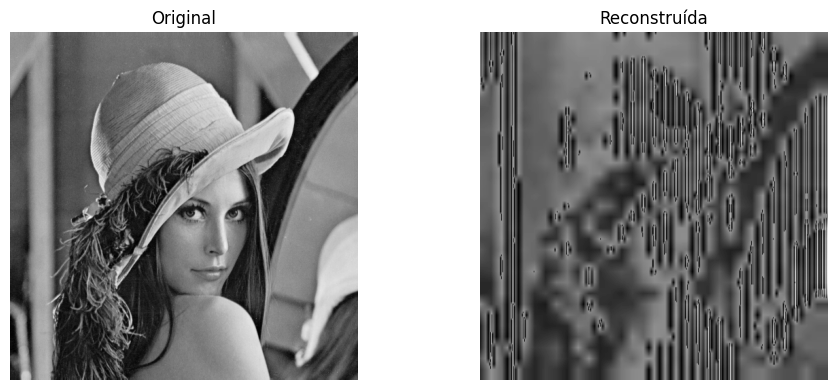

In [15]:
### Código da questão 1d.

# interpola imagem em linhas e depois em colunas
def interpolar_imagem(A):
    h, w = A.shape

    # interpola colunas
    B = np.zeros((h, 2 * w))
    for i in range(h):
        linha_interp = interpolar(A[i, :])
        B[i, :] = linha_interp

    # interpola linhas
    C = np.zeros((2 * h, 2 * w))
    for j in range(2 * w):
        col_interp = interpolar(B[:, j])
        C[:, j] = col_interp

    return C.astype(np.uint8)

A_int = A_dec.copy()
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(A_int, cmap='gray')
axes[0].set_title(f"Entrada\n{A_int.shape[0]}x{A_int.shape[1]}")
axes[0].axis('off')

for i in range(4):
    A_int = interpolar_imagem(A_int)
    axes[i + 1].imshow(A_int, cmap='gray')
    axes[i + 1].set_title(f"Passo {i+1}\n{A_int.shape[0]}x{A_int.shape[1]}")
    axes[i + 1].axis('off')

plt.suptitle("Questão 1d")
plt.tight_layout()
plt.show()

# comparação original com reconstruída
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(A, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(A_int, cmap='gray')
axes[1].set_title("Reconstruída")
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Questão 2

Considere o seguinte sistema LDIT:
$$ y\left[n+2\right] + \frac{1}{6}y\left[n\right] = x\left[n+2\right] + 2x\left[n+1\right]+x\left[n\right] $$
$$ x\left[n\right] = \left(\frac{1}{4}\right)^n u\left[n\right] $$
$$ y\left[-1\right] = y\left[-2\right] = 0 $$

## Questão 2a (1 ponto)

Determine a resposta ao impulso h[n] analiticamente. Você pode inserir a sua resposta escaneada como uma imagem abaixo.

<img src="1.2a.jpeg" width="600">

## Questão 2b (1 ponto)
Escreva um código para obter a resposta ao impulso h[n] iterativamente. Compare a resposta obtida iterativamente com a resposta analítica para as primeiras 100 amostras, plotando o gráfico das duas respostas.

Calcule também o erro médio quadrático entre os dois sinais, h[n] analítico e g[n] iterativo, através da equação:

$$ MSE = \frac{1}{N} \sum_{i=0}^{N-1} \left( h\left[i\right] - g\left[i\right] \right)^2 $$

onde N é o número de amostras considerado (no caso, 100 amostras).

MSE: 1.195011e-40


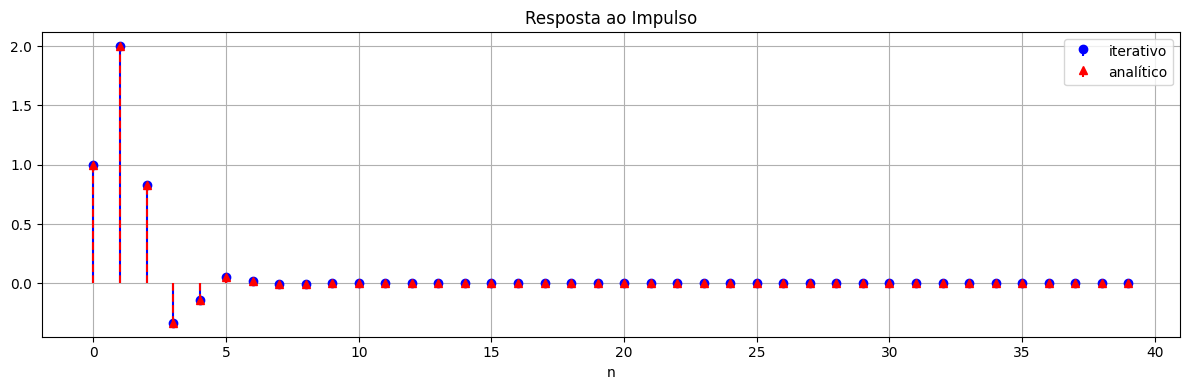

In [16]:
### Código da questão 2b.

N = 100
h_iter = np.zeros(N)

# entrada é o impulso unitário
x_delta = np.zeros(N)
x_delta[0] = 1

for n in range(N):
    termo_x = x_delta[n]
    if n >= 1:
        termo_x = termo_x + 2 * x_delta[n - 1]
    if n >= 2:
        termo_x = termo_x + x_delta[n - 2]
        h_iter[n] = termo_x - (1.0 / 6.0) * h_iter[n - 2]
    else:
        h_iter[n] = termo_x

# resposta de referência via scipy
b_coef = [1, 2, 1]
a_coef = [1, 0, 1/6]
_, h_analitico = sig.dimpulse((b_coef, a_coef, 1), n=N)
h_analitico = h_analitico[0].ravel()

ns = np.arange(N)
mse_2b = np.mean((h_iter - h_analitico) ** 2)
print(f"MSE: {mse_2b:.6e}")

plt.figure(figsize=(12, 4))
plt.stem(ns[:40], h_iter[:40], linefmt='b-', markerfmt='bo', basefmt=' ', label='iterativo')
plt.stem(ns[:40], h_analitico[:40], linefmt='r--', markerfmt='r^', basefmt=' ', label='analítico')
plt.title("Resposta ao Impulso")
plt.xlabel("n")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Questão 2c (1 ponto)

Determine a resposta do sistema às condições iniciais dadas analiticamente. Você pode inserir a sua resposta escaneada como uma imagem abaixo.

<img src="1.2c.jpeg" width="600">

In [17]:
N_ci = 100
y_ci = np.zeros(N_ci)
y_ant1 = 0  # y[-1]
y_ant2 = 0  # y[-2]

for n in range(N_ci):
    y_ci[n] = -(1.0 / 6.0) * y_ant2
    y_ant2 = y_ant1
    y_ant1 = y_ci[n]

print("Resposta às CIs (primeiras 5 amostras):", y_ci[:5])

Resposta às CIs (primeiras 5 amostras): [-0. -0.  0.  0. -0.]


### Questão 2d (1 ponto)
Escreva um programa para obter a resposta do sistema através da convolução da entrada com a resposta ao impulso h[n] truncada para as primeiras 20 amostras (isto é, considerando apenas as primeiras 20 amostras de h[n]).

Compare a resposta obtida pela convolução com a resposta obtida analiticamente, plotando o gráfico das duas respostas (calcule as primeiras 100 amostras do sinal). Calcule também o erro médio quadrático entre os dois sinais.

MSE: 7.285466e-17


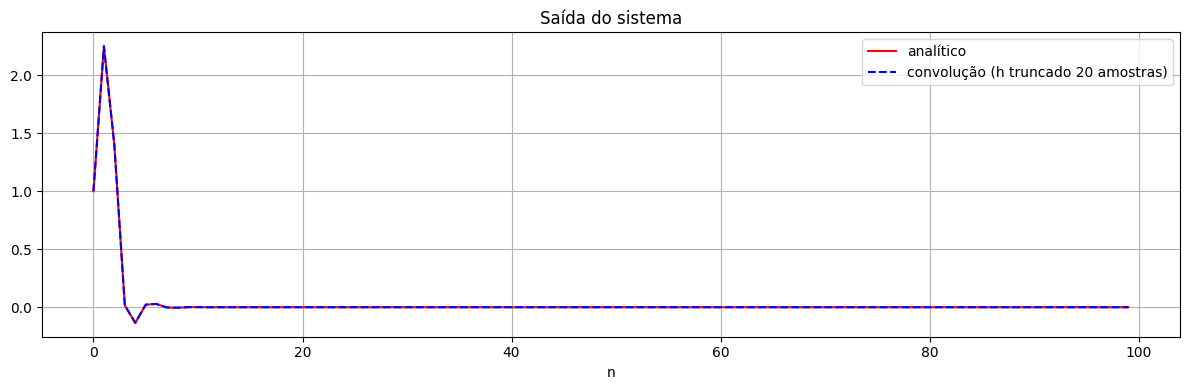

In [18]:
### Código da questão 2d.


ns = np.arange(N)
x_entrada = (1.0 / 4.0) ** ns

h_truncado = h_iter[:20]
y_conv = np.convolve(x_entrada, h_truncado)[:N]

# resposta de referência
y_ref = sig.lfilter(b_coef, a_coef, x_entrada)

mse_2d = np.mean((y_conv - y_ref) ** 2)
print(f"MSE: {mse_2d:.6e}")

plt.figure(figsize=(12, 4))
plt.plot(ns, y_ref, 'r-', label='analítico', linewidth=1.5)
plt.plot(ns, y_conv, 'b--', label='convolução (h truncado 20 amostras)')
plt.title("Saída do sistema")
plt.xlabel("n")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Questão 2e (1 ponto)

Usando como entrada o sinal disponibilizado ('data_projeto1.mat'), determine a resposta do sistema. Plote o gráfico da entrada e da saída do sistema. 

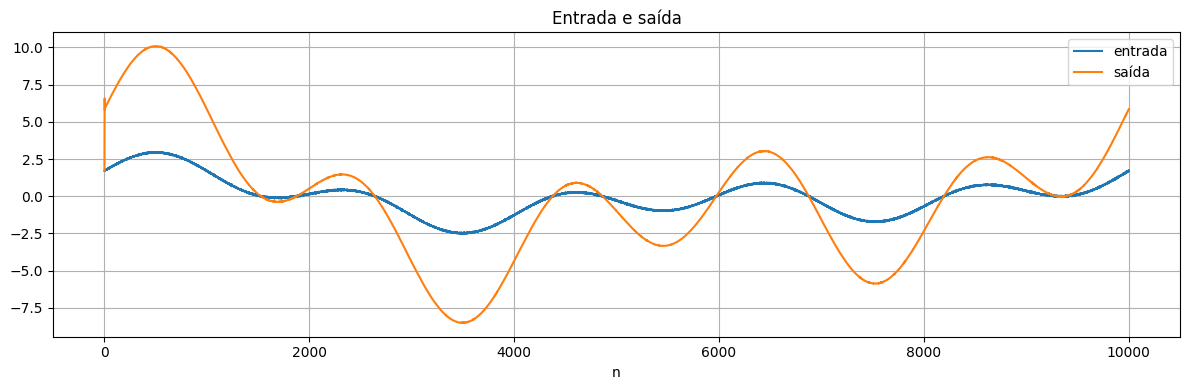

In [19]:
### Códgio da Questão 2e

sinal = sp.io.loadmat('data_projeto1.mat')['sinal'].ravel()
y_saida = sig.lfilter(b_coef, a_coef, sinal)

plt.figure(figsize=(12, 4))
plt.plot(sinal, label='entrada')
plt.plot(y_saida, label='saída')
plt.title("Entrada e saída")
plt.xlabel("n")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Questão 3
Considere o seguinte sistema LDIT:
$$ y\left[n+2\right] -2~\cos \left( \frac{\pi}{8} \right) y\left[n+1\right] + y\left[n\right] = x\left[n\right] $$

## Questão 3a (1 ponto)
Determine a resposta ao impulso h[n] analiticamente. Você pode inserir a sua resposta escaneada como uma imagem abaixo.

<img src="1.3a.jpeg" width="600">

## Questão 3b (1 ponto)
Escreva um programa para obter a resposta ao impulso h[n] iterativamente. Compare a resposta obtida com a resposta analítica, plotando o gráfico das duas respostas para as primeiras 100 amostras. Calcule também o erro médio quadrático entre os dois sinais.

MSE: 1.748868e-29


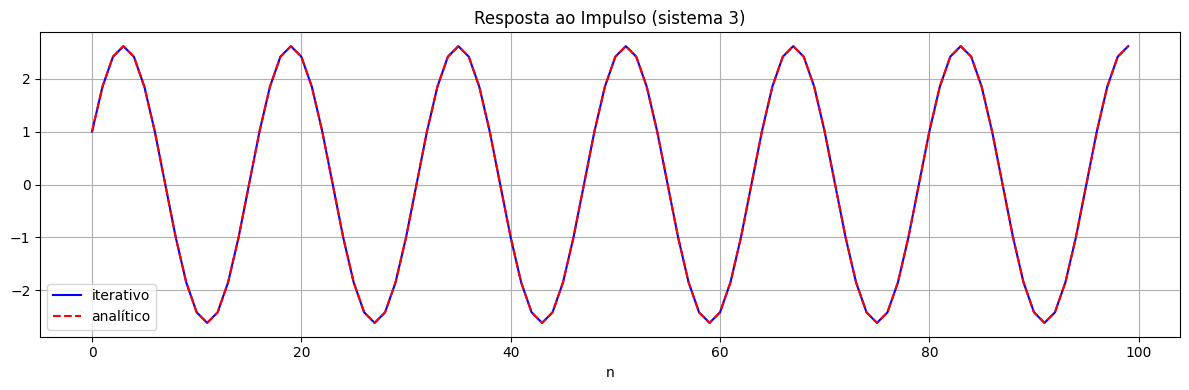

In [21]:
### Código da questão 3b


# reorganizando: y[n] = x[n] + 2cos(pi/8)y[n-1] - y[n-2]

N3 = 100
h3_iter = np.zeros(N3)
delta3 = np.zeros(N3)
delta3[0] = 1

c = 2 * np.cos(np.pi / 8)

for n in range(N3):
    h3_iter[n] = delta3[n]
    if n >= 1:
        h3_iter[n] = h3_iter[n] + c * h3_iter[n - 1]
    if n >= 2:
        h3_iter[n] = h3_iter[n] - h3_iter[n - 2]

# fórmula analítica
ns3 = np.arange(N3)
h3_analitico = (1.0 / np.sin(np.pi / 8)) * np.sin((ns3 + 1) * np.pi / 8)

mse_3b = np.mean((h3_iter - h3_analitico) ** 2)
print(f"MSE: {mse_3b:.6e}")

plt.figure(figsize=(12, 4))
plt.plot(ns3, h3_iter, 'b-', label='iterativo')
plt.plot(ns3, h3_analitico, 'r--', label='analítico')
plt.title("Resposta ao Impulso (sistema 3)")
plt.xlabel("n")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()